In [3]:
import sys
import pandas as pd
import numpy as np

sys.path.append('../') 

from src.data_loader import TimeSeriesDataLoader

loader = TimeSeriesDataLoader()

file_path = '../data/raw/Internal Submission Hourly 2024.csv' 
df = loader.load_and_clean(file_path)
df.head()

Loading data from ../data/raw/Internal Submission Hourly 2024.csv...
Data cleaned. Total baris: 8784


,Carbon intensity gCO₂eq/kWh (direct),Carbon-free energy percentage (CFE%),Renewable energy percentage (RE%)
Datetime (UTC),,,
2024-01-01 00:00:00,584.32,16.06,16.06
2024-01-01 01:00:00,580.70,16.19,16.19
2024-01-01 02:00:00,575.88,16.56,16.56
2024-01-01 03:00:00,577.33,16.41,16.41
2024-01-01 04:00:00,577.58,16.37,16.37


In [4]:
print(df.head())
print(df.info())
print(df.columns)

                     Carbon intensity gCO₂eq/kWh (direct)  \
Datetime (UTC)                                              
2024-01-01 00:00:00                                584.32   
2024-01-01 01:00:00                                580.70   
2024-01-01 02:00:00                                575.88   
2024-01-01 03:00:00                                577.33   
2024-01-01 04:00:00                                577.58   

                     Carbon-free energy percentage (CFE%)  \
Datetime (UTC)                                              
2024-01-01 00:00:00                                 16.06   
2024-01-01 01:00:00                                 16.19   
2024-01-01 02:00:00                                 16.56   
2024-01-01 03:00:00                                 16.41   
2024-01-01 04:00:00                                 16.37   

                     Renewable energy percentage (RE%)  
Datetime (UTC)                                          
2024-01-01 00:00:00           

In [5]:
df["hour"] = df.index.hour # hour (0-25)
df["day_of_week"] = df.index.dayofweek # Day of Week (0=Senin, ..., 6=Minggu)
df["month"] = df.index.month # Month (1–12)

df.head() 

,Carbon intensity gCO₂eq/kWh (direct),Carbon-free energy percentage (CFE%),Renewable energy percentage (RE%),hour,day_of_week,month
Datetime (UTC),,,,,,
2024-01-01 00:00:00,584.32,16.06,16.06,0,0,1
2024-01-01 01:00:00,580.70,16.19,16.19,1,0,1
2024-01-01 02:00:00,575.88,16.56,16.56,2,0,1
2024-01-01 03:00:00,577.33,16.41,16.41,3,0,1
2024-01-01 04:00:00,577.58,16.37,16.37,4,0,1


In [6]:
hour_dummy = pd.get_dummies(df["hour"], prefix="H") # daily (H-1-H24)
month_dummy = pd.get_dummies(df["month"], prefix="B") # Monthly (B1-B12)
df = pd.concat([df, hour_dummy, month_dummy], axis=1)

print(df.shape)
df.head()

(8784, 42)


,Carbon intensity gCO₂eq/kWh (direct),Carbon-free energy percentage (CFE%),Renewable energy percentage (RE%),hour,day_of_week,month,H_0,H_1,H_2,H_3,...,B_3,B_4,B_5,B_6,B_7,B_8,B_9,B_10,B_11,B_12
Datetime (UTC),,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,584.32,16.06,16.06,0,0,1,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2024-01-01 01:00:00,580.70,16.19,16.19,1,0,1,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2024-01-01 02:00:00,575.88,16.56,16.56,2,0,1,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2024-01-01 03:00:00,577.33,16.41,16.41,3,0,1,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2024-01-01 04:00:00,577.58,16.37,16.37,4,0,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df["week_hour"] = ("M" + (df["day_of_week"] + 1).astype(str) + "H" + (df["hour"] + 1).astype(str)) # Weekly x Hour Interaction (7 × 24)
week_hour_dummy = pd.get_dummies(df["week_hour"])   
df = pd.concat([df, week_hour_dummy], axis=1)

print(df.shape)
df.head()

(8784, 211)


,Carbon intensity gCO₂eq/kWh (direct),Carbon-free energy percentage (CFE%),Renewable energy percentage (RE%),hour,day_of_week,month,H_0,H_1,H_2,H_3,...,M7H22,M7H23,M7H24,M7H3,M7H4,M7H5,M7H6,M7H7,M7H8,M7H9
Datetime (UTC),,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,584.32,16.06,16.06,0,0,1,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2024-01-01 01:00:00,580.70,16.19,16.19,1,0,1,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2024-01-01 02:00:00,575.88,16.56,16.56,2,0,1,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2024-01-01 03:00:00,577.33,16.41,16.41,3,0,1,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2024-01-01 04:00:00,577.58,16.37,16.37,4,0,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


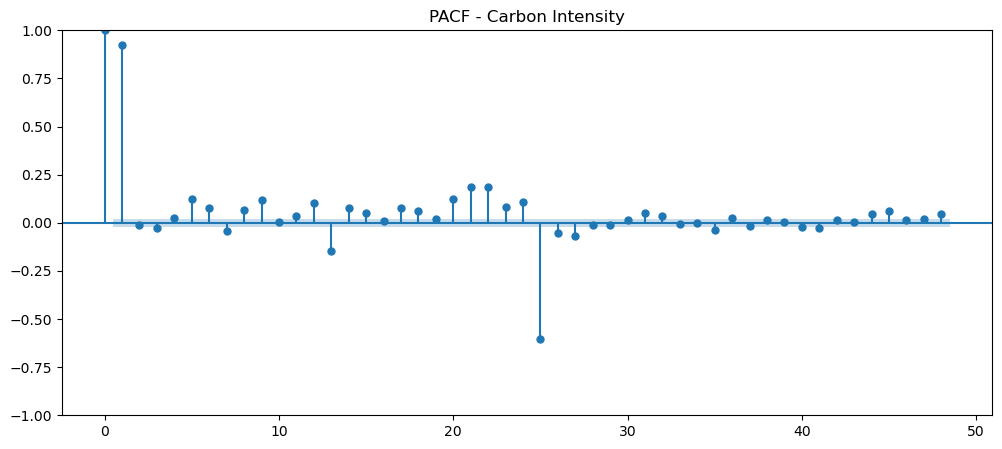

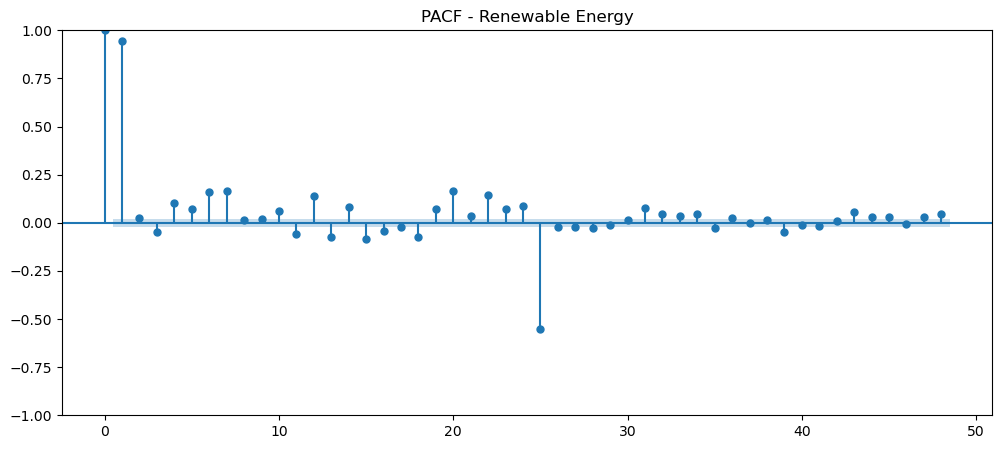

In [8]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,5))

plot_pacf(df["Carbon intensity gCO₂eq/kWh (direct)"], lags=48, method="ywm", alpha=0.05, ax=ax)

plt.title("PACF - Carbon Intensity")
plt.show()

fig, ax = plt.subplots(figsize=(12,5))

plot_pacf(df["Renewable energy percentage (RE%)"], lags=48, method="ywm", alpha=0.05,ax=ax)

plt.title("PACF - Renewable Energy")
plt.show()

In [9]:
target = "Carbon intensity gCO₂eq/kWh (direct)"

df["lag_1"] = df[target].shift(1)
df["lag_12"] = df[target].shift(12)
df["lag_24"] = df[target].shift(24)

df[["lag_1", "lag_12", "lag_24"]].head(30)

,lag_1,lag_12,lag_24
Datetime (UTC),,,
2024-01-01 00:00:00,NaN,NaN,NaN
2024-01-01 01:00:00,584.32,NaN,NaN
2024-01-01 02:00:00,580.70,NaN,NaN
2024-01-01 03:00:00,575.88,NaN,NaN
2024-01-01 04:00:00,577.33,NaN,NaN
2024-01-01 05:00:00,577.58,NaN,NaN
2024-01-01 06:00:00,575.08,NaN,NaN
2024-01-01 07:00:00,578.76,NaN,NaN
2024-01-01 08:00:00,575.46,NaN,NaN


In [10]:
# Menghapus baris yang memiliki NaN akibat lag
df = df.dropna()

print(df.shape)
df.head()

(8760, 214)


,Carbon intensity gCO₂eq/kWh (direct),Carbon-free energy percentage (CFE%),Renewable energy percentage (RE%),hour,day_of_week,month,H_0,H_1,H_2,H_3,...,M7H3,M7H4,M7H5,M7H6,M7H7,M7H8,M7H9,lag_1,lag_12,lag_24
Datetime (UTC),,,,,,,,,,,,,,,,,,,,,
2024-01-02 00:00:00,581.45,16.26,16.26,0,1,1,True,False,False,False,...,False,False,False,False,False,False,False,584.23,573.51,584.32
2024-01-02 01:00:00,578.25,16.31,16.31,1,1,1,False,True,False,False,...,False,False,False,False,False,False,False,581.45,573.19,580.70
2024-01-02 02:00:00,580.18,15.97,15.97,2,1,1,False,False,True,False,...,False,False,False,False,False,False,False,578.25,576.81,575.88
2024-01-02 03:00:00,580.73,15.91,15.91,3,1,1,False,False,False,True,...,False,False,False,False,False,False,False,580.18,576.38,577.33
2024-01-02 04:00:00,582.02,15.86,15.86,4,1,1,False,False,False,False,...,False,False,False,False,False,False,False,580.73,583.79,577.58


In [11]:
target_col = "Carbon intensity gCO₂eq/kWh (direct)"

feature_cols = [target_col,"lag_1", "lag_12", "lag_24"]

feature_cols += [col for col in df.columns if col.startswith("H_")] # Daily Dummy (H1-H24)
feature_cols += [col for col in df.columns if col.startswith("M")] # Weekly Interaction (M1H1 - M7H24)
feature_cols += [col for col in df.columns if col.startswith("B_")] # Monthly Dummy (B1-B12)

print(f"Total feature: {len(feature_cols)}")
print(feature_cols[:10])

Total feature: 208
['Carbon intensity gCO₂eq/kWh (direct)', 'lag_1', 'lag_12', 'lag_24', 'H_0', 'H_1', 'H_2', 'H_3', 'H_4', 'H_5']


In [12]:
missing = [col for col in feature_cols if col not in df.columns]

print("Missing columns:", missing)

Missing columns: []


In [13]:
train_df, test_df = loader.split_and_scale(df, feature_cols=feature_cols, train_ratio=0.8)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Splitting and Scaling data...
Train shape: (7008, 208)
Test shape : (1752, 208)


In [14]:
look_back = 24          # menggunakan histori 24 jam
forecast_horizon = 1    # memprediksi 1 jam ke depan

print("\nCreating sliding windows...")

X_train, y_train = loader.create_sliding_window(train_df, look_back, forecast_horizon)
X_test, y_test = loader.create_sliding_window(test_df, look_back, forecast_horizon)

print("\n--- Hasil Dimensi Array ---")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)


Creating sliding windows...

--- Hasil Dimensi Array ---
X_train shape: (6984, 24, 208)
y_train shape: (6984, 1)
X_test shape : (1728, 24, 208)
y_test shape : (1728, 1)


In [15]:
num_features = X_train.shape[2]

print("Jumlah fitur:", num_features)

Jumlah fitur: 208


In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

num_features = X_train.shape[2]

model_uni = Sequential([LSTM(units=64, return_sequences=False, input_shape=(look_back, num_features)), Dropout(0.2), Dense(units=1)])
model_uni.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

model_uni.summary()

C:\Users\ASUS ZENBOOK\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        69,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,953 (273.25 KB)

 Trainable params: 69,953 (273.25 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
callbacks = [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True), ModelCheckpoint('../saved_models/dl_weights/univariate_lstm_best.keras', save_best_only=True)]
print("Memulai Training Model Univariate LSTM...")

history_uni = model_uni.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, callbacks=callbacks, verbose=1)

Memulai Training Model Univariate LSTM...
Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0026 - mae: 0.0394 - val_loss: 0.0071 - val_mae: 0.0711
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0023 - mae: 0.0374 - val_loss: 0.0103 - val_mae: 0.0870
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0022 - mae: 0.0363 - val_loss: 0.0083 - val_mae: 0.0783
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0021 - mae: 0.0355 - val_loss: 0.0117 - val_mae: 0.0944
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0020 - mae: 0.0346 - val_loss: 0.0098 - val_mae: 0.0860
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0019 - mae: 0.0338 - val_loss: 0.0110 - val_mae: 0.0918
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0019 - mae: 0.0334 - val_loss: 0.0091 - val_mae: 0.0835
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0018 - mae: 0.0331 - val_loss: 0.0101 - val_mae: 0.0878
Epoch 9/50
219

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Melakukan prediksi...")

y_pred_scaled = model_uni.predict(X_test)

y_test_asli = loader.target_scaler.inverse_transform(y_test)
y_pred_asli = loader.target_scaler.inverse_transform(y_pred_scaled)

Melakukan prediksi...
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [25]:
mae = mean_absolute_error(y_test_asli, y_pred_asli)
rmse = np.sqrt(mean_squared_error(y_test_asli, y_pred_asli))
mape = np.mean(np.abs((y_test_asli - y_pred_asli) / y_test_asli)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 3.75
RMSE : 4.44
MAPE : 0.64%


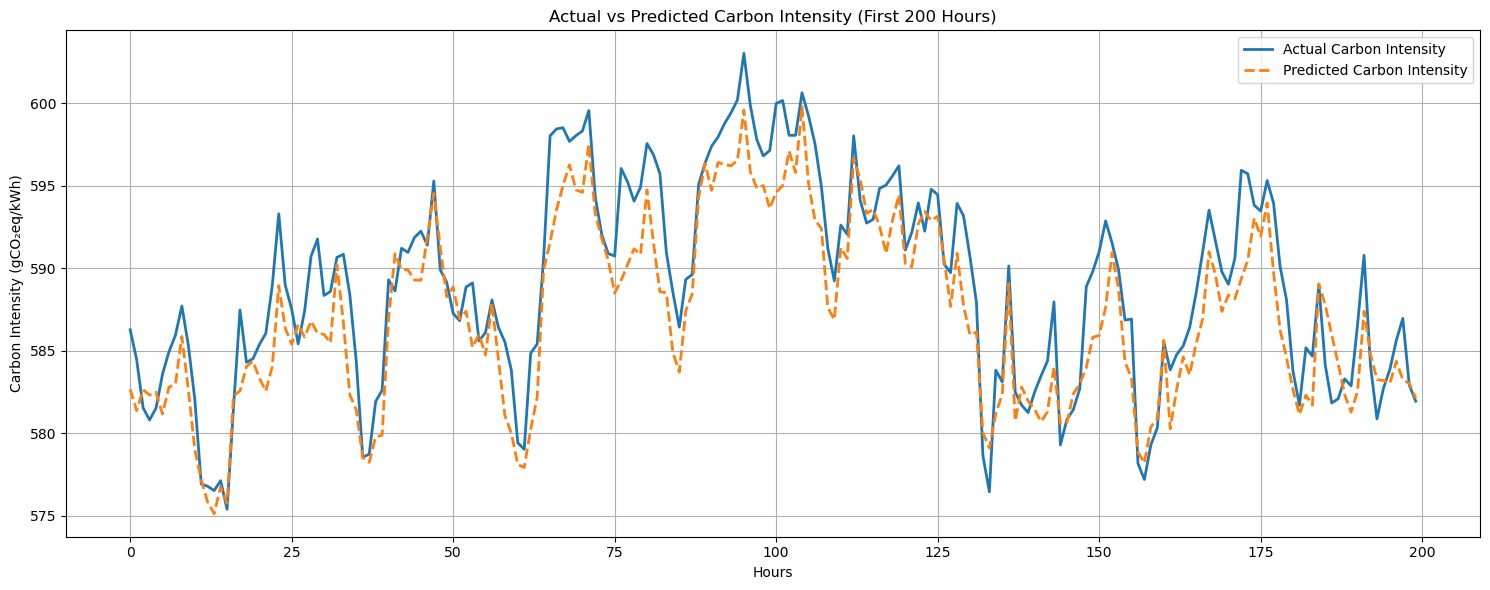

In [27]:
# Visualisasi hasil prediksi
plot_hours = 200

plt.figure(figsize=(15, 6))

plt.plot(y_test_asli[:plot_hours], label="Actual Carbon Intensity", linewidth=2)

plt.plot(y_pred_asli[:plot_hours], label="Predicted Carbon Intensity", linestyle="--", linewidth=2)

plt.title("Actual vs Predicted Carbon Intensity (First 200 Hours)")
plt.xlabel("Hours")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()